In [1]:
import os
import numpy as np
from sklearn.utils import class_weight

TRAIN_PATH = 'master_dataset/dataset_kesegaran_buah/train'

# 1. Audit Jumlah Data
folders = sorted([f for f in os.listdir(TRAIN_PATH) if not f.startswith('.')])
class_counts = {folder: len(os.listdir(os.path.join(TRAIN_PATH, folder))) for folder in folders}

print("=== HASIL AUDIT DATASET KESEGARAN ===")
for cls, count in class_counts.items():
    print(f"Kelas {cls}: {count} gambar")

# 2. Hitung Class Weight Otomatis (Binary)
labels = []
for i, folder in enumerate(folders):
    labels.extend([i] * class_counts[folder])

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = {i: weight for i, weight in enumerate(weights)}
print(f"\n[INFO] Bobot Kelas: {class_weight_dict}")

=== HASIL AUDIT DATASET KESEGARAN ===
Kelas fresh: 4740 gambar
Kelas unfresh: 6161 gambar

[INFO] Bobot Kelas: {0: 1.1498945147679325, 1: 0.8846778120434994}


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary', 
    shuffle=True
)

test_generator = val_test_datagen.flow_from_directory(
    'master_dataset/dataset_kesegaran_buah/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 10901 images belonging to 2 classes.
Found 2698 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model_freshness = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid') # Output Binary
])

model_freshness.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_freshness.summary()

2026-05-03 21:36:17.299146: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-03 21:36:17.299485: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-03 21:36:17.299506: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-03 21:36:17.299827: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-03 21:36:17.299861: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint('models/model_freshness_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

print("[INFO] Memulai training Model 3...")
history = model_freshness.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, lr_reducer]
)

[INFO] Memulai training Model 3...
Epoch 1/30


2026-05-03 21:38:16.621416: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7832 - loss: 0.4491
Epoch 1: val_accuracy improved from None to 0.94774, saving model to models/model_freshness_best.h5



Epoch 1: finished saving model to models/model_freshness_best.h5
341/341 ━━━━━━━━━━━━━━━━━━━━ 87s 233ms/step - accuracy: 0.8652 - loss: 0.3046 - val_accuracy: 0.9477 - val_loss: 0.1394 - learning_rate: 1.0000e-04
Epoch 2/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9276 - loss: 0.1857
Epoch 2: val_accuracy improved from 0.94774 to 0.95923, saving model to models/model_freshness_best.h5



Epoch 2: finished saving model to models/model_freshness_best.h5
341/341 ━━━━━━━━━━━━━━━━━━━━ 74s 217ms/step - accuracy: 0.9269 - loss: 0.1824 - val_accuracy: 0.9592 - val_loss: 0.1130 - learning_rate: 1.0000e-04
Epoch 3/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9334 - loss: 0.1630
Epoch 3: val_accuracy improved from 0.95923 to 0.96738, saving model to models/model_freshness_best.h5


...


Epoch 6: finished saving model to models/model_freshness_best.h5
341/341 ━━━━━━━━━━━━━━━━━━━━ 95s 277ms/step - accuracy: 0.9456 - loss: 0.1343 - val_accuracy: 0.9733 - val_loss: 0.0821 - learning_rate: 1.0000e-04
Epoch 7/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9491 - loss: 0.1302
Epoch 7: val_accuracy improved from 0.97331 to 0.97554, saving model to models/model_freshness_best.h5



Epoch 7: finished saving model to models/model_freshness_best.h5
341/341 ━━━━━━━━━━━━━━━━━━━━ 84s 246ms/step - accuracy: 0.9466 - loss: 0.1383 - val_accuracy: 0.9755 - val_loss: 0.0765 - learning_rate: 1.0000e-04
Epoch 8/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9483 - loss: 0.1271
Epoch 8: val_accuracy did not improve from 0.97554
341/341 ━━━━━━━━━━━━━━━━━━━━ 81s 236ms/step - accuracy: 0.9487 - loss: 0.1265 - val_accuracy: 0.9755 - val_loss: 0.0745 - learning_rate: 1.0000e-04
Epoch 9/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9544 - loss: 0.1182
Epoch 9: val_accuracy improved from 0.97554 to 0.97702, saving model to models/model_freshness_best.h5



Epoch 9: finished saving model to models/model_freshness_best.h5
341/341 ━━━━━━━━━━━━━━━━━━━━ 82s 239ms/step - accuracy: 0.9504 - loss: 0.1236 - val_accuracy: 0.9770 - val_loss: 0.0718 - learning_rate: 1.0000e-04
Epoch 10/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9495 - loss: 0.1266
Epoch 10: val_accuracy did not improve from 0.97702
341/341 ━━━━━━━━━━━━━━━━━━━━ 84s 245ms/step - accuracy: 0.9523 - loss: 0.1210 - val_accuracy: 0.9766 - val_loss: 0.0720 - learning_rate: 1.0000e-04
Epoch 11/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9523 - loss: 0.1194
Epoch 11: val_accuracy did not improve from 0.97702
341/341 ━━━━━━━━━━━━━━━━━━━━ 85s 248ms/step - accuracy: 0.9508 - loss: 0.1225 - val_accuracy: 0.9729 - val_loss: 0.0736 - learning_rate: 1.0000e-04
Epoch 12/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9500 - loss: 0.1325
Epoch 12: val_accuracy did not improve from 0.97702
341/341 ━━━━━━━━━━━━━━━━━━━━ 84s 246ms/step - accuracy: 0.9504 - lo


Epoch 13: finished saving model to models/model_freshness_best.h5
341/341 ━━━━━━━━━━━━━━━━━━━━ 81s 236ms/step - accuracy: 0.9526 - loss: 0.1203 - val_accuracy: 0.9778 - val_loss: 0.0696 - learning_rate: 1.0000e-04
Epoch 14/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9509 - loss: 0.1230
Epoch 14: val_accuracy improved from 0.97776 to 0.97924, saving model to models/model_freshness_best.h5



Epoch 14: finished saving model to models/model_freshness_best.h5
341/341 ━━━━━━━━━━━━━━━━━━━━ 80s 234ms/step - accuracy: 0.9500 - loss: 0.1276 - val_accuracy: 0.9792 - val_loss: 0.0705 - learning_rate: 1.0000e-04
Epoch 15/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9508 - loss: 0.1235
Epoch 15: val_accuracy did not improve from 0.97924
341/341 ━━━━━━━━━━━━━━━━━━━━ 80s 235ms/step - accuracy: 0.9503 - loss: 0.1230 - val_accuracy: 0.9766 - val_loss: 0.0714 - learning_rate: 1.0000e-04
Epoch 16/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9527 - loss: 0.1159
Epoch 16: val_accuracy did not improve from 0.97924
341/341 ━━━━━━━━━━━━━━━━━━━━ 82s 240ms/step - accuracy: 0.9522 - loss: 0.1195 - val_accuracy: 0.9770 - val_loss: 0.0706 - learning_rate: 1.0000e-04
Epoch 17/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9554 - loss: 0.1197
Epoch 17: val_accuracy did not improve from 0.97924
341/341 ━━━━━━━━━━━━━━━━━━━━ 85s 249ms/step - accuracy: 0.9536 - l

In [ ]:

import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Konfigurasi Path & Hyperparameters
TEST_PATH = 'master_dataset/dataset_kesegaran_buah/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Re-inisialisasi Test Generator 
val_test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# 3. Load Model dari Disk ke RAM
model_path = 'models/model_freshness_best.h5'
if os.path.exists(model_path):
    model_freshness = tf.keras.models.load_model(model_path)
    print("[SUCCESS] Model Freshness & Generator siap digunakan!")
else:
    print(f"[ERROR] File {model_path} tidak ditemukan. Cek folder 'models' kamu.")

Found 2698 images belonging to 2 classes.


2026-05-04 14:15:39.765355: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-04 14:15:39.765556: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-04 14:15:39.765565: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-04 14:15:39.766103: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 14:15:39.766116: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[SUCCESS] Model Freshness & Generator siap digunakan!


[info] mengonfigurasi test generator untuk evaluasi...
[info] melakukan prediksi pada dataset test freshness...


2026-05-04 14:15:45.435751: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step


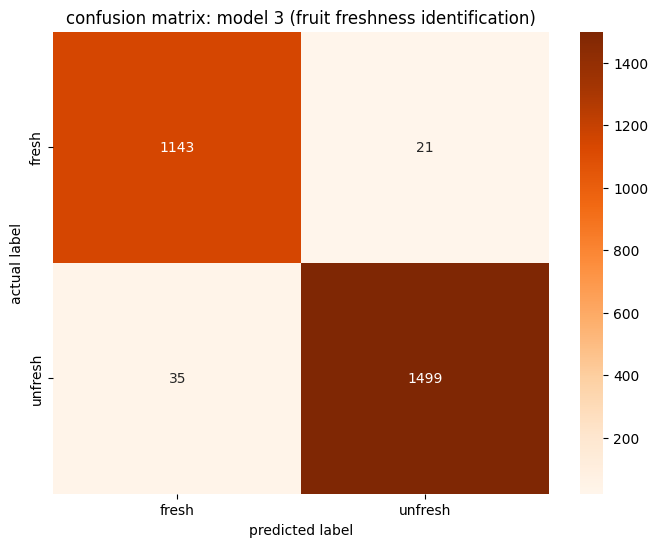


hasil evaluasi performa model 3 (freshness)
              precision    recall  f1-score   support

       fresh     0.9703    0.9820    0.9761      1164
     unfresh     0.9862    0.9772    0.9817      1534

    accuracy                         0.9792      2698
   macro avg     0.9782    0.9796    0.9789      2698
weighted avg     0.9793    0.9792    0.9793      2698

total accuracy (global): 97.92%


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. konfigurasi test generator ---
print("[info] mengonfigurasi test generator untuk evaluasi...")
test_generator.reset()

# --- 2. proses inferensi (logika binary) ---
print("[info] melakukan prediksi pada dataset test freshness...")
# model.predict akan menghasilkan nilai antara 0 sampai 1
Y_pred = model_freshness.predict(test_generator, verbose=1)
# jika nilai > 0.5 maka dianggap kelas 1 (fresh), jika <= 0.5 dianggap kelas 0 (unfresh)
y_pred = (Y_pred > 0.5).astype("int32").flatten()
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- 3. generate confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('confusion matrix: model 3 (fruit freshness identification)')
plt.ylabel('actual label')
plt.xlabel('predicted label')
plt.show()

# --- 4. statistik metrik bab 4 ---
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
print("\n" + "="*60)
print("hasil evaluasi performa model 3 (freshness)")
print("="*60)
print(report)

overall_accuracy = accuracy_score(y_true, y_pred)
print(f"total accuracy (global): {overall_accuracy * 100:.2f}%")
print("="*60)

In [6]:
import json

# ambil mapping dari generator
class_indices_freshness = test_generator.class_indices
# simpan ke folder models
json_path = 'models/class_indices_freshness.json'
with open(json_path, 'w') as f:
    json.dump(class_indices_freshness, f, indent=4)

print(f"[success] label map model 3 disimpan di: {json_path}")
print("isi label map:", class_indices_freshness)

[success] label map model 3 disimpan di: models/class_indices_freshness.json
isi label map: {'fresh': 0, 'unfresh': 1}


In [3]:
import time

def benchmark_freshness(num_trials=50):
    # ambil satu sampel gambar
    images, _ = next(test_generator)
    single_img = np.expand_dims(images[0], axis=0)
    
    print(f"[info] memulai benchmark model 3 pada {num_trials} percobaan...")
    
    start_time = time.time()
    for _ in range(num_trials):
        # proses prediksi di macbook m2
        _ = model_freshness.predict(single_img, verbose=0)
    end_time = time.time()
    
    avg_time = (end_time - start_time) / num_trials
    fps = 1 / avg_time
    
    print("\n" + "="*40)
    print("hasil benchmark latensi model 3 (apple m2)")
    print("="*40)
    print(f"rata-rata waktu inferensi : {avg_time * 1000:.2f} ms")
    print(f"estimasi throughput       : {fps:.2f} fps")
    print("="*40)

benchmark_freshness()

[info] memulai benchmark model 3 pada 50 percobaan...

hasil benchmark latensi model 3 (apple m2)
rata-rata waktu inferensi : 80.92 ms
estimasi throughput       : 12.36 fps
